# Неделя 1 — EDA

Задание: `docs/week1_eda.md`

## 1. Загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.eda import explore, churn_rate_by


In [2]:
# Клиенты
clients = pd.read_excel('../data/raw/clients.xlsx')

# Помесячное потребление - лежит по месяцам, читаем и склеиваем один раз,
# дальше работаем только с parquet (см. docs/data_dictionary.md)
import glob
usage_files = sorted(glob.glob('../data/raw/usage/*.csv'))
usage = pd.concat([pd.read_csv(f) for f in usage_files], ignore_index=True)

clients.to_parquet('../data/processed/clients.parquet')
usage.to_parquet('../data/processed/usage.parquet')
print(clients.shape, usage.shape)

# Проверяем уникальность client_id в clients. Нет ли дубликатов и повторов
print("Уникальных client_id:", clients["client_id"].nunique())
print("Всего строк:", len(clients))
print("Дубликатов client_id:", clients["client_id"].duplicated().sum())

# Проверяем уникальность пары client_id + month в usage
duplicates_usage = usage.duplicated(
    subset=["client_id", "month"]
).sum()

print("Дубликатов client_id + month:", duplicates_usage)

# Проверяем, что все клиенты из usage существуют в clients
clients_ids = set(clients["client_id"])
usage_ids = set(usage["client_id"])

missing_clients = usage_ids - clients_ids

print("Клиентов в usage, которых нет в clients:", len(missing_clients))

print(sorted(usage["month"].unique()))
print("Количество месяцев:", usage["month"].nunique())
print(usage.groupby("month")["client_id"].nunique())


(50400, 8) (1073079, 7)
Уникальных client_id: 50400
Всего строк: 50400
Дубликатов client_id: 0
Дубликатов client_id + month: 0
Клиентов в usage, которых нет в clients: 0
['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']
Количество месяцев: 30
month
2024-01    27572
2024-02    28433
2024-03    29346
2024-04    30198
2024-05    30904
2024-06    31527
2024-07    32156
2024-08    32818
2024-09    33438
2024-10    34097
2024-11    34635
2024-12    35230
2025-01    35788
2025-02    36344
2025-03    36824
2025-04    37297
2025-05    37758
2025-06    38221
2025-07    38564
2025-08    38889
2025-09    39183
2025-10    39464
2025-11    39709
2025-12    39992
2026-01    40265
2026-02    40448
2026-03    39718
2026-04    

## 2. Чек-лист EDA

Пройдитесь по 7 вопросам из `docs/week1_eda.md` для каждой таблицы.

In [3]:
explore(clients, "Клиенты")
explore(usage, "Помесячное потребление")

===== Клиенты =====
Размер: 50400 строк, 8 столбцов
                     тип  пропусков  пропусков_%  уникальных
client_id         object          0          0.0       50400
segment           object          0          0.0           3
product           object          0          0.0           4
region            object          0          0.0           5
company_name      object          0          0.0       19360
connection_date   object          0          0.0          58
termination_date  object      36361         72.1          27
current_status    object          0          0.0           2
===== Помесячное потребление =====
Размер: 1073079 строк, 7 столбцов
                тип  пропусков  пропусков_%  уникальных
client_id    object          0          0.0       50400
month        object          0          0.0          30
revenue     float64          0          0.0     1016925
traffic_gb  float64          0          0.0       26650
n_tickets     int64          0          0.0       

,тип,пропусков,пропусков_%,уникальных
client_id,object,0,0.0,50400
month,object,0,0.0,30
revenue,float64,0,0.0,1016925
traffic_gb,float64,0,0.0,26650
n_tickets,int64,0,0.0,13
debt,float64,0,0.0,76454
n_sim,int64,0,0.0,348


In [4]:
# Сколько месяцев наблюдается у каждого клиента

months_per_client = (
    usage.groupby("client_id")["month"]
    .nunique()
)

print(months_per_client.describe())
print("Клиентов с 1 месяцем:", (months_per_client == 1).sum())
print("Клиентов с 2 месяцами:", (months_per_client == 2).sum())
print("Клиентов с 3 месяцами:", (months_per_client == 3).sum())
print("Клиентов со всеми 30 месяцами:", (months_per_client == 30).sum())

count    50400.000000
mean        21.291250
std          9.127167
min          3.000000
25%         13.000000
50%         24.000000
75%         30.000000
max         30.000000
Name: month, dtype: float64
Клиентов с 1 месяцем: 0
Клиентов с 2 месяцами: 0
Клиентов с 3 месяцами: 27
Клиентов со всеми 30 месяцами: 19985


In [5]:
# Проверяем последовательность месяцев внутри истории каждого клиента

usage_check = usage.copy()

usage_check["month"] = pd.to_datetime(usage_check["month"])

gaps = []

for client_id, group in usage_check.groupby("client_id"):
    months = group["month"].sort_values()
    
    if len(months) > 1:
        differences = months.diff().dropna()
        
        if (differences > pd.Timedelta(days=40)).any():
            gaps.append(client_id)

print("Клиентов с подозрительными дырами:", len(gaps))
print(clients["connection_date"].value_counts().sort_index())

Клиентов с подозрительными дырами: 0
connection_date
2021-07    875
2021-08    903
2021-09    951
2021-10    913
2021-11    922
2021-12    864
2022-01    924
2022-02    843
2022-03    901
2022-04    911
2022-05    869
2022-06    898
2022-07    920
2022-08    846
2022-09    844
2022-10    927
2022-11    886
2022-12    919
2023-01    853
2023-02    896
2023-03    879
2023-04    880
2023-05    898
2023-06    887
2023-07    822
2023-08    948
2023-09    873
2023-10    851
2023-11    895
2023-12    865
2024-01    909
2024-02    861
2024-03    913
2024-04    852
2024-05    930
2024-06    870
2024-07    877
2024-08    918
2024-09    910
2024-10    987
2024-11    852
2024-12    923
2025-01    916
2025-02    950
2025-03    898
2025-04    918
2025-05    939
2025-06    971
2025-07    912
2025-08    902
2025-09    900
2025-10    872
2025-11    912
2025-12    926
2026-01    934
2026-02    930
2026-03     28
2026-04     27
Name: count, dtype: int64


In [6]:
clients["termination_date"] = pd.to_datetime(
    clients["termination_date"],
    format="%Y-%m",
    errors="coerce"
)

clients["connection_date"] = pd.to_datetime(
    clients["connection_date"],
    format="%Y-%m"
)

print("Самая ранняя дата подключения:",
      clients["connection_date"].min())

print("Самая поздняя дата подключения:",
      clients["connection_date"].max())

print("Самая ранняя дата расторжения:",
      clients["termination_date"].min())

print("Самая поздняя дата расторжения:",
      clients["termination_date"].max())

Самая ранняя дата подключения: 2021-07-01 00:00:00
Самая поздняя дата подключения: 2026-04-01 00:00:00
Самая ранняя дата расторжения: 2024-04-01 00:00:00
Самая поздняя дата расторжения: 2026-06-01 00:00:00


In [7]:
usage_clients = usage["client_id"].nunique()
clients_total = clients["client_id"].nunique()

matched_clients = usage[
    usage["client_id"].isin(clients["client_id"])
]["client_id"].nunique()

print("Всего клиентов в clients:", clients_total)
print("Клиентов в usage:", usage_clients)
print("Сопоставлено:", matched_clients)
print(
    "Доля сопоставленных:",
    round(matched_clients / usage_clients * 100, 2),
    "%"
)

Всего клиентов в clients: 50400
Клиентов в usage: 50400
Сопоставлено: 50400
Доля сопоставленных: 100.0 %


In [8]:
# т.к 100% client_id из usage находятся в clients, то:

In [9]:
# Базовая метка оттока для EDA.
# Клиент считается ушедшим, если на конец периода
# (июнь 2026) его текущий статус — "Расторгнут".

clients["is_churned"] = (
    clients["current_status"] == "Расторгнут"
).astype(int)

print("Всего клиентов:", len(clients))
print("Ушедших:", clients["is_churned"].sum())
print("Оставшихся:", (clients["is_churned"] == 0).sum())
print(
    "Доля оттока:",
    round(clients["is_churned"].mean() * 100, 2),
    "%"
)

Всего клиентов: 50400
Ушедших: 14039
Оставшихся: 36361
Доля оттока: 27.86 %


## 3. Доля оттока по сегментам/продуктам/регионам

In [10]:
print("=== Отток по сегментам ===")
print(
    churn_rate_by(
        clients,
        target_col="is_churned",
        group_col="segment"
    )
)

print("\n=== Отток по продуктам ===")
print(
    churn_rate_by(
        clients,
        target_col="is_churned",
        group_col="product"
    )
)

print("\n=== Отток по регионам ===")
print(
    churn_rate_by(
        clients,
        target_col="is_churned",
        group_col="region"
    )
)

=== Отток по сегментам ===
                доля_оттока  клиентов
segment                              
малый бизнес       0.308758     24388
средний бизнес     0.275953     17079
крупный бизнес     0.201052      8933

=== Отток по продуктам ===
                  доля_оттока  клиентов
product                                
мобильная связь      0.279978     12676
облачные сервисы     0.279628     12463
телефония            0.279243     12627
интернет             0.275368     12634

=== Отток по регионам ===
                 доля_оттока  клиентов
region                                
Юг                  0.285502     10105
Москва              0.281824      9914
Урал                0.276446     10096
Санкт-Петербург     0.275450     10118
Сибирь              0.273630     10167


## 4. Динамика ушедших vs оставшихся клиентов

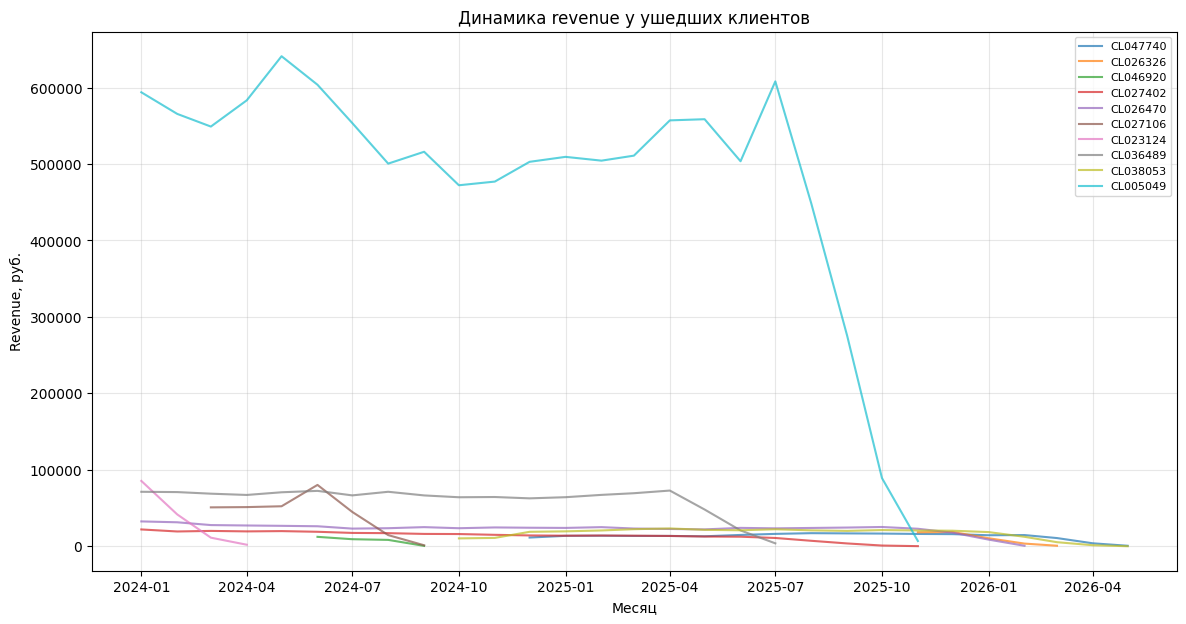

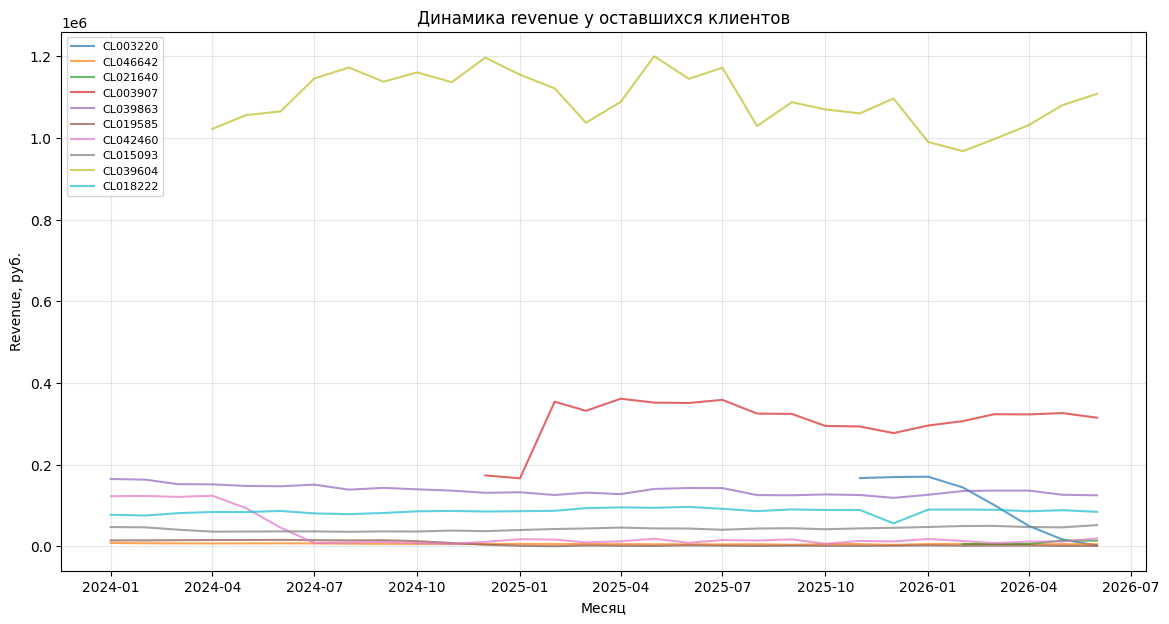

In [11]:
# TODO: построить графики revenue во времени для 5-10 ушедших и 5-10 оставшихся клиентов

# Добавляем статус клиента к помесячным данным
usage_with_status = usage.merge(
    clients[["client_id", "is_churned"]],
    on="client_id",
    how="left"
)

usage_with_status["month"] = pd.to_datetime(
    usage_with_status["month"]
)

# Выбираем 10 ушедших и 10 оставшихся клиентов
churned_clients = (
    clients.loc[clients["is_churned"] == 1, "client_id"]
    .sample(10, random_state=42)
)

active_clients = (
    clients.loc[clients["is_churned"] == 0, "client_id"]
    .sample(10, random_state=42)
)

plt.figure(figsize=(14, 7))

for client_id in churned_clients:
    client_data = usage_with_status[
        usage_with_status["client_id"] == client_id
    ].sort_values("month")
    
    plt.plot(
        client_data["month"],
        client_data["revenue"],
        alpha=0.7,
        label=client_id
    )

plt.title("Динамика revenue у ушедших клиентов")
plt.xlabel("Месяц")
plt.ylabel("Revenue, руб.")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()



plt.figure(figsize=(14, 7))

for client_id in active_clients:
    client_data = usage_with_status[
        usage_with_status["client_id"] == client_id
    ].sort_values("month")
    
    plt.plot(
        client_data["month"],
        client_data["revenue"],
        alpha=0.7,
        label=client_id
    )

plt.title("Динамика revenue у оставшихся клиентов")
plt.xlabel("Месяц")
plt.ylabel("Revenue, руб.")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()


In [12]:
print("Полных дубликатов в clients:", clients.duplicated().sum())
print("Полных дубликатов в usage:", usage.duplicated().sum())
print("Минимальные значения в usage:")
print(
    usage[["revenue", "traffic_gb", "n_tickets", "debt", "n_sim"]].min()
)

Полных дубликатов в clients: 0
Полных дубликатов в usage: 0
Минимальные значения в usage:
revenue       5.61
traffic_gb    0.00
n_tickets     0.00
debt          0.00
n_sim         0.00
dtype: float64


**отрицательных значений нет из блока выше**

`Важные сведения clients:`

50 400 клиентов

50 400 уникальных client_id

0 дубликатов client_id

0 полных дубликатов


`usage:`

0 дубликатов client_id + month

0 полных дубликатов

100% client_id существуют в clients

30 месяцев наблюдения

## 5. Выводы

TODO: сформулируйте 3-5 наблюдений об аномалиях, объёме данных и первой проверке гипотезы про сегменты.

1. **Объём и структура данных.**  
   Таблица клиентов содержит 50 400 уникальных клиентов, а таблица помесячного потребления — 1 073 079 записей за 30 месяцев с января 2024 по июнь 2026. Дубликатов по ключам и полных дубликатов не обнаружено. Все клиенты из `usage` присутствуют в таблице `clients`, доля сопоставленных клиентов составляет 100%.

2. **Период наблюдения.**  
   Для клиентов доступно от 3 до 30 месяцев истории, медиана составляет 24 месяца. У 19 985 клиентов есть данные за все 30 месяцев. Подозрительных пропусков месяцев внутри истории клиентов не обнаружено.

3. **Аномалии и выбросы.**  
   Пропусков в числовых признаках `usage` нет, отрицательных значений также не обнаружено. При этом присутствуют сильные выбросы: максимальный `revenue` составляет около 10,78 млн руб., а максимальный `traffic_gb` — около 11 640 ГБ. Эти значения требуют дополнительной проверки на следующих этапах анализа.

4. **Базовый уровень оттока.**  
   На конец периода наблюдения (июнь 2026) доля ушедших клиентов составляет 27,86%: 14 039 клиентов из 50 400. По продуктам и регионам различия относительно небольшие: отток по продуктам находится примерно в диапазоне 27,5–28,0%, по регионам — 27,4–28,6%.

5. **Первая проверка гипотезы о сегментах.**  
   Сегмент показывает существенно более сильную связь с оттоком, чем продукт или регион. Доля оттока составляет 30,88% для малого бизнеса, 27,60% для среднего и 20,11% для крупного бизнеса. Разница между малым и крупным бизнесом составляет 10,77 п.п., поэтому сегмент является перспективным признаком для дальнейшего моделирования и анализа причин оттока. Графики `revenue` также показывают, что у части ушедших клиентов перед расторжением наблюдается заметное снижение или резкое обнуление выручки.